# Pipeline de Engenharia de Dados e Normalização de PDV — KAlimentos
**Disciplina:** Inteligência Artificial II (2026/02) | **Faculdade Antonio Meneghetti (AMF)**  
**Objetivo:** Reorganização do pipeline de dados, diagnóstico de inconsistências de escala em embalagens e segmentação não supervisionada de pedidos.

## 1. Setup do Ambiente e Configurações Globais
Nesta etapa inicial:
- Importamos as bibliotecas necessárias para manipulação, estatística e modelagem.
- Fixamos as constantes globais e parâmetros determinísticos (`RANDOM_STATE = 42`) conforme as boas práticas do PEP 8.
- Configuramos a exibição tabular do Pandas para auditoria detalhada de preços e SKUs.

In [18]:
# 1.1 Imports essenciais
import numpy as np
import pandas as pd
from skimpy import skim
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2 Constantes Globais (PEP 8)
RANDOM_STATE = 42
TIMEZONE = 'America/Sao_Paulo'
RAW_DATA_PATH = './studing/KalimentosFeirasVendas.csv'
PROCESSED_DATA_PATH = 'base.csv'
TOLERANCIA_FINANCEIRA = 0.01

# 1.3 Configurações de Exibição do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Carga dos Dados e Auditoria de Integridade Financeira
Carregamos o dataset bruto `KalimentosFeirasVendas.csv` garantindo sua **imutabilidade estrita** (conforme os guardrails de integridade em `AGENTS.md`).

Antes de qualquer manipulação:
1. Preservamos o nome bruto original em `nome_produto_bruto` para rastreabilidade comparativa.
2. Padronizamos a nomenclatura das colunas (eliminando abreviações e unificando no padrão pt-BR).
3. Descartamos `pedido_vendedor` (e `item_pedido_user_id`) logo no início: no PDV de feiras, múltiplos atendentes compartilham o mesmo caixa/login, corrompendo a granularidade do operador e tornando a variável sem relevância preditiva.
4. Validamos o balanço contábil fundamental do PDV:
$$\text{pedido\_subtotal} - \text{pedido\_valor\_desconto} \equiv \text{valor\_final\_pedido}$$

In [19]:
# Carga dos dados brutos
df = pd.read_csv(RAW_DATA_PATH)
df = df.convert_dtypes()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pedido_id                   3115 non-null   string 
 1   pedido_valor_total          3115 non-null   Float64
 2   pedido_data                 3115 non-null   string 
 3   pedido_tipo_desconto        3115 non-null   string 
 4   pedido_valor_desconto       3115 non-null   Float64
 5   pedido_subtotal             3115 non-null   Int64  
 6   pedido_vendedor             3115 non-null   string 
 7   pedido_metodo_pagamento     3115 non-null   string 
 8   item_pedido_nome_produto    3115 non-null   string 
 9   item_pedido_quantidade      3115 non-null   Int64  
 10  item_pedido_preco_unitario  3115 non-null   Float64
 11  item_pedido_user_id         3115 non-null   string 
 12  evento_nome                 3115 non-null   string 
dtypes: Float64(3), Int64(2), string(8)
memory us

In [20]:
# Preservação explícita da coluna original para auditoria comparativa
df['nome_produto_bruto'] = df['item_pedido_nome_produto']

# Renomeação padronizada de colunas
df.rename(columns={
    'pedido_valor_total': 'valor_final_pedido',
    'pedido_metodo_pagamento': 'metodo_pagamento',
    'item_pedido_nome_produto': 'nome_produto',
    'item_pedido_quantidade': 'quantidade_item',
    'item_pedido_preco_unitario': 'preco_unitario_item'
}, inplace=True)

df.head()

,pedido_id,valor_final_pedido,pedido_data,pedido_tipo_desconto,pedido_valor_desconto,pedido_subtotal,pedido_vendedor,metodo_pagamento,nome_produto,quantidade_item,preco_unitario_item,item_pedido_user_id,evento_nome,nome_produto_bruto
0,a231f36f-be88-492c-b719-23830b22fb4b,20.00,2026-03-09 17:31:54.325-03,%,0.00,20,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Alfajor Preto (Pacote x4),1,20.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Alfajor Preto (Pacote x4)
1,d47eb20b-e24f-4c70-92f9-9b554eb8f280,15.00,2026-03-10 10:27:12.241-03,%,0.00,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Cuca Enrolada de Amendoim,1,15.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cuca Enrolada de Amendoim
2,d3b5b66d-d9e1-4924-b507-144e0e0b9ef9,15.00,2026-03-10 11:17:14.665-03,%,0.00,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cuca Enrolada de Amendoim,1,15.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cuca Enrolada de Amendoim
3,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.00,2026-03-10 12:02:08.319-03,%,0.00,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Alfajor Preto,1,6.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Alfajor Preto
4,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.00,2026-03-10 12:02:08.319-03,%,0.00,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cri-Cri 200g,1,7.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cri-Cri 200g


In [21]:
# Verificação da invariante contábil (pedido_subtotal - pedido_valor_desconto == valor_final_pedido)
divergencias_financeiras = df.query('abs(pedido_valor_desconto - (pedido_subtotal - valor_final_pedido)) > @TOLERANCIA_FINANCEIRA')
print(f"Registros com divergência financeira detectada: {len(divergencias_financeiras)}")

# Eliminação de colunas redundantes ou corrompidas (compartilhamento de login de operador no PDV)
df = df.drop(columns=['pedido_tipo_desconto', 'item_pedido_user_id', 'pedido_vendedor'])

# Conversão de tipos de data e subtotal
df['pedido_data'] = pd.to_datetime(df['pedido_data'], format='mixed')
df['pedido_subtotal'] = df['pedido_subtotal'].astype('Float64')

df.info()

Registros com divergência financeira detectada: 0
<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   pedido_id              3115 non-null   string                   
 1   valor_final_pedido     3115 non-null   Float64                  
 2   pedido_data            3115 non-null   datetime64[us, UTC-03:00]
 3   pedido_valor_desconto  3115 non-null   Float64                  
 4   pedido_subtotal        3115 non-null   Float64                  
 5   metodo_pagamento       3115 non-null   string                   
 6   nome_produto           3115 non-null   string                   
 7   quantidade_item        3115 non-null   Int64                    
 8   preco_unitario_item    3115 non-null   Float64                  
 9   evento_nome            3115 non-null   string                   
 10  nome_prod

## 3. Diagnóstico Exploratório de Inconsistências (Preço, Quantidade e Embalagens)
### O Desafio das Unidades Fracionadas vs. Fechadas no PDV
Nas feiras coloniais, determinados itens são vendidos tanto em formato unitário quanto em embalagens coletivas (ex.: *Caixa x16*, *Pacote x6*, *Bandeja x5*).  
Observa-se que em diversos registros o operador do caixa apontou o preço total do fardo/caixa mantendo a quantidade unitária (ou vice-versa), gerando dispersões atípicas no desvio padrão dos preços.

Abaixo, inspecionamos essas variações **antes** de qualquer agrupamento semântico para isolar os casos com maior desvio padrão (`preco_std`).

In [22]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 3115   │ │ string      │ 5     │                                                          │
│ │ Number of columns │ 11     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ datetime64  │ 1     │                                                          │
│                                │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                     ┃ NA  ┃ NA %   ┃ mean     ┃ sd      ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │     valor_final_pedido     │   0 │      0 │    46.97 │   210.1 │   0 │   15 │   25 │   35 │  3693 │   █    │  │
│ │   pedido_valor_desconto    │   0 │      0 │   0.3634 │   2.752 │   0 │    0 │    0 │    0 │    83 │   █    │  │
│ │      pedido_subtotal       │   0 │      0 │    47.33 │   210.4 │   5 │   15 │   25 │   35 │  3696 │   █    │  │
│ │      quantidade_item       │   0 │      0 │    2.667 │   8.486 │   0 │    1 │    1 │    3 │   348 │   █    │  │
│ │    preco_unitario_item     │   0 │      0 │    13.29 │   8.654 │   4 │    6 │    8 │   25 │    80 │   █▄   │  │
│ └────────────────────────────┴─────┴────────┴──────────┴─────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃ column        ┃ NA  ┃ NA %  ┃ first                          ┃ last                           ┃ frequency  ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │  pedido_data  │   0 │     0 │   2026-03-09 09:05:04.177000   │   2026-09-06 18:15:55.440000   │ None       │  │
│ └───────────────┴─────┴───────┴────────────────────────────────┴────────────────────────────────┴────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ pedido_id │  0 │    0 │ a231f36f- │ a231f36f- │ 0055b17b- │ ffdb4e8c- │        36 │         1 │       3115 │  │
│ │           │    │      │ be88-492c │ be88-492c │ e0ca-4884 │ 85ab-4125 │           │           │            │  │
│ │           │    │      │ -b719-238 │ -b719-238 │ -afc9-309 │ -b0e8-fa0 │           │           │            │  │
│ │           │    │      │ 30b22fb4b │ 30b22fb4b │ 823f

In [23]:
# Análise de dispersão por produto bruto (fiel ao describe() da Cell 6 original)
resumo_precos = df.groupby('nome_produto_bruto').agg(
    n_registros=('pedido_id', 'count'),
    preco_min=('preco_unitario_item', 'min'),
    preco_max=('preco_unitario_item', 'max'),
    preco_medio=('preco_unitario_item', 'mean'),
    preco_std=('preco_unitario_item', 'std'),
    qtd_min=('quantidade_item', 'min'),
    qtd_max=('quantidade_item', 'max'),
    qtd_media=('quantidade_item', 'mean')
).sort_values(by='preco_std', ascending=False)

resumo_precos

,n_registros,preco_min,preco_max,preco_medio,preco_std,qtd_min,qtd_max,qtd_media
nome_produto_bruto,,,,,,,,
Alfajor Preto (Caixa x16),12,5.00,80.00,36.25,38.62,0,16,14.67
Rapadura Assada (Pacote x6),253,4.17,25.00,9.60,9.17,1,348,9.12
Alfajor Preto (Pacote x4),152,5.00,20.00,10.03,7.11,1,72,4.84
Rapadura de Melado (Pacote x3),198,6.67,20.00,9.16,5.21,1,12,3.32
Cri-Cri 200g,104,7.00,8.00,7.94,0.23,1,19,1.48
Alfajor Branco (Caixa x16),2,5.00,5.00,5.00,0.00,16,16,16.00
Alfajor Preto,189,6.00,6.00,6.00,0.00,1,15,1.74
Alfajor Branco (Pacote x4),19,5.00,5.00,5.00,0.00,4,4,4.00
Alfajor Preto (Display x1),14,5.00,5.00,5.00,0.00,1,97,8.07


In [24]:
# Filtragem de itens críticos com embalagens coletivas (ex.: Caixa x16, Pacote x6, Pacote x4)
itens_criticos = df[df['nome_produto_bruto'].str.contains('Caixa x16|Pacote x6|Pacote x4|Bandeja x5', na=False, case=False)]

itens_criticos[['pedido_id', 'nome_produto_bruto', 'quantidade_item', 'preco_unitario_item', 'pedido_subtotal', 'valor_final_pedido']].head(15)

,pedido_id,nome_produto_bruto,quantidade_item,preco_unitario_item,pedido_subtotal,valor_final_pedido
0,a231f36f-be88-492c-b719-23830b22fb4b,Alfajor Preto (Pacote x4),1,20.00,20.00,20.00
13,67dc9591-f502-47de-a874-b56af2d4c5b6,Rapadura Assada (Pacote x6),1,25.00,32.00,32.00
22,e633a701-71c7-43d2-878a-27b8ee0fad46,Rapadura Assada (Pacote x6),24,25.00,100.00,100.00
29,7a0e3c5d-1276-4aa5-b6ab-c51d7afd3c9c,Alfajor Preto (Pacote x4),1,20.00,20.00,20.00
53,3e0e8bf8-a313-4b11-8ab1-48ea524a2ffc,Alfajor Preto (Pacote x4),8,20.00,40.00,40.00
54,9ec2e76d-9312-4420-b010-d702ed9c5753,Rapadura Assada (Pacote x6),6,25.00,30.00,30.00
62,85020602-a515-4a05-bb98-5ec754b352b9,Rapadura Assada (Pacote x6),6,25.00,25.00,25.00
67,e98a95aa-7cda-405e-bf27-56bac4807d97,Alfajor Preto (Pacote x4),8,20.00,40.00,40.00
73,54aa47bb-a187-4243-a372-9586569d8151,Rapadura Assada (Pacote x6),6,25.00,25.00,25.00
75,fa3b508d-9a5a-4a91-bc00-3b31c519c6c6,Alfajor Preto (Pacote x4),4,20.00,20.00,20.00


## 4. Validação de Integridade Transacional (Data Quality — Itens vs. Subtotal)
Nesta etapa, auditamos a consistência matemática no nível mais granular da transação:  
A soma do valor total dos itens de cada pedido deve equivaler rigorosamente ao subtotal registrado no cabeçalho:

$$\text{subtotal\_calculado}(p) = \sum_{i \in p} (\text{quantidade\_item}_i \times \text{preco\_unitario\_item}_i)$$
$$\Delta(p) = \text{subtotal\_calculado}(p) - \text{subtotal\_esperado}(p)$$

Aplicamos a tolerância de arredondamento de $R\$\,0,01$ (`np.isclose` com `atol=TOLERANCIA_FINANCEIRA`).
Essa auditoria isola com precisão os pedidos que sofreram distorções de escala decorrentes de embalagens múltiplas antes da etapa de mapeamento.

In [25]:
# 4.1 Cálculo do valor total por linha de item
df['item_total_calculado'] = df['quantidade_item'] * df['preco_unitario_item']

# 4.2 Agregação por pedido
auditoria_pedidos = df.groupby('pedido_id').agg(
    subtotal_esperado=('pedido_subtotal', 'first'),
    subtotal_calculado=('item_total_calculado', 'sum'),
    qtd_linhas=('nome_produto_bruto', 'count'),
    qtd_itens_total=('quantidade_item', 'sum')
).reset_index()

# 4.3 Cálculo de delta e teste de conformidade via np.isclose
auditoria_pedidos['delta'] = auditoria_pedidos['subtotal_calculado'] - auditoria_pedidos['subtotal_esperado']
auditoria_pedidos['abs_delta'] = auditoria_pedidos['delta'].abs()
auditoria_pedidos['divergente'] = ~np.isclose(
    auditoria_pedidos['subtotal_calculado'], 
    auditoria_pedidos['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)

# 4.4 Resumo Executivo de Data Quality
total_pedidos = len(auditoria_pedidos)
total_divergentes = int(auditoria_pedidos['divergente'].sum())
total_validos = total_pedidos - total_divergentes
pct_validos = (total_validos / total_pedidos) * 100
pct_divergentes = (total_divergentes / total_pedidos) * 100

resumo_dq = pd.DataFrame({
    'Métrica': [
        'Total de Pedidos Únicos',
        'Pedidos Íntegros / Válidos (Δ ≤ 0.01)',
        'Pedidos com Divergência (Δ > 0.01)',
        'Taxa de Conformidade (%)',
        'Taxa de Divergência (%)',
        'Delta Médio nos Divergentes (R$)',
        'Maior Delta Absoluto Detectado (R$)'
    ],
    'Valor': [
        f"{total_pedidos:,}",
        f"{total_validos:,}",
        f"{total_divergentes:,}",
        f"{pct_validos:.2f}%",
        f"{pct_divergentes:.2f}%",
        f"R$ {auditoria_pedidos.query('divergente')['abs_delta'].mean():.2f}",
        f"R$ {auditoria_pedidos['abs_delta'].max():.2f}"
    ]
})

print("=== RESUMO EXECUTIVO DE INTEGRIDADE DE DADOS (DATA QUALITY) ===")
resumo_dq


=== RESUMO EXECUTIVO DE INTEGRIDADE DE DADOS (DATA QUALITY) ===


,Métrica,Valor
0,Total de Pedidos Únicos,"2,457"
1,Pedidos Íntegros / Válidos (Δ ≤ 0.01),"2,318"
2,Pedidos com Divergência (Δ > 0.01),139
3,Taxa de Conformidade (%),94.34%
4,Taxa de Divergência (%),5.66%
5,Delta Médio nos Divergentes (R$),R$ 140.86
6,Maior Delta Absoluto Detectado (R$),R$ 1450.00


In [26]:
# Relação completa dos pedidos divergentes ordenada pela magnitude do erro
pedidos_divergentes = auditoria_pedidos.query('divergente').sort_values(
    by='abs_delta', 
    ascending=False
).drop(columns=['divergente'])

print(f"Total de pedidos com divergência de cálculo: {len(pedidos_divergentes)}")
pedidos_divergentes.head(25)

Total de pedidos com divergência de cálculo: 139


,pedido_id,subtotal_esperado,subtotal_calculado,qtd_linhas,qtd_itens_total,delta,abs_delta
383,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,130.00,1580.00,2,28,1450.00,1450.00
884,5ecf70b3-e227-4b3c-83ed-60efffb3d187,113.00,1438.00,3,23,1325.00,1325.00
25,03239939-8db0-44f2-a1c0-8631040d6cbb,80.00,1280.00,1,16,1200.00,1200.00
1115,75de3a74-f410-473b-8583-b12470a61e05,80.00,1280.00,1,16,1200.00,1200.00
1006,6ad66d8a-5d74-4ade-be8c-668184af824a,80.00,1280.00,1,16,1200.00,1200.00
2202,e633a701-71c7-43d2-878a-27b8ee0fad46,100.00,600.00,1,24,500.00,500.00
2354,f4ac49c3-f010-46b8-b2fb-51acf2acee26,70.00,380.00,2,16,310.00,310.00
233,1bf6b30e-ae89-443d-b6db-28d0c8328cfe,72.00,322.00,3,15,250.00,250.00
1015,6b6753ce-c59b-4768-a7fd-90841b9d4e22,50.00,300.00,1,12,250.00,250.00
1825,beabc1ae-ff7a-48dc-bd67-b91867f6f2e8,56.00,306.00,2,13,250.00,250.00


In [27]:
# Registros transacionais detalhados dos itens nos pedidos divergentes
df_itens_divergentes = df[df['pedido_id'].isin(pedidos_divergentes['pedido_id'])][
    [
        'pedido_id', 
        'nome_produto_bruto', 
        'quantidade_item', 
        'preco_unitario_item', 
        'item_total_calculado', 
        'pedido_subtotal', 
        'valor_final_pedido'
    ]
].sort_values(by=['pedido_subtotal', 'pedido_id'], ascending=[False, True])

print(f"Total de registros de itens em pedidos com divergência: {len(df_itens_divergentes)}")
df_itens_divergentes.head(30)

Total de registros de itens em pedidos com divergência: 185


,pedido_id,nome_produto_bruto,quantidade_item,preco_unitario_item,item_total_calculado,pedido_subtotal,valor_final_pedido
278,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,Rapadura Assada (Pacote x6),12,25.00,300.00,130.00,130.00
279,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,Alfajor Preto (Caixa x16),16,80.00,1280.00,130.00,130.00
266,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Alfajor Preto (Caixa x16),16,80.00,1280.00,113.00,112.00
267,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Rapadura Assada (Pacote x6),6,25.00,150.00,113.00,112.00
268,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Amendoim salgado e temperado,1,8.00,8.00,113.00,112.00
22,e633a701-71c7-43d2-878a-27b8ee0fad46,Rapadura Assada (Pacote x6),24,25.00,600.00,100.00,100.00
303,03239939-8db0-44f2-a1c0-8631040d6cbb,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
295,6ad66d8a-5d74-4ade-be8c-668184af824a,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
151,75de3a74-f410-473b-8583-b12470a61e05,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
384,1bf6b30e-ae89-443d-b6db-28d0c8328cfe,Rapadura Assada (Pacote x6),12,25.00,300.00,72.00,72.00


In [28]:
# Frequência de produtos nos pedidos com divergência de cálculo
ranking_produtos_divergentes = df_itens_divergentes['nome_produto_bruto'].value_counts().reset_index()
ranking_produtos_divergentes.columns = ['Produto (Nome Bruto)', 'Total de Ocorrências em Pedidos Divergentes']

print("=== PRODUTOS MAIS FREQUENTES NOS PEDIDOS COM DIVERGÊNCIA ===")
ranking_produtos_divergentes

=== PRODUTOS MAIS FREQUENTES NOS PEDIDOS COM DIVERGÊNCIA ===


,Produto (Nome Bruto),Total de Ocorrências em Pedidos Divergentes
0,Rapadura Assada (Pacote x6),62
1,Alfajor Preto (Pacote x4),45
2,Rapadura de Melado (Pacote x3),36
3,Rapadura de Melado,9
4,Alfajor Preto,7
5,Rapadura Assada,7
6,Cuca Enrolada de Amendoim,6
7,Alfajor Preto (Caixa x16),5
8,Amendoim salgado e temperado,3
9,Pé-de-Moleque,3


## 5. Agrupamento Semântico e Consolidação de Produtos
Nesta seção, isolamos a higienização textual e o dicionário de mapeamento de produtos (`mapa_produtos`).  
Desta forma, é possível testar e expandir os agrupamentos de forma modular, sem interferir nas colunas de auditoria originais (`nome_produto_bruto`).

In [29]:
# Higienização básica de strings
df['nome_produto'] = df['nome_produto'].str.strip(" ")
df['nome_produto'] = df['nome_produto'].str.replace(' ', '_').str.upper()

# Dicionário de mapeamento semântico do autor
mapa_produtos = {
    'CUCA_ALEMÃ': 'CUCA_ALEMÃ',
    'PÉ-DE-MOLEQUE': 'PÉ-DE-MOLEQUE',
    'AMENDOIM_SALGADO_E_TEMPERADO': 'AMENDOIM_TEMPERADO',
    # 'AMENDOIM_TEMPERADO_100G': 'AMENDOIM_TEMPERADO',
    'RAPADURA_ASSADA': 'RAPADURA_ASSADA',
    # 'RAPADURA_ASSADA_(PACOTE_X6)': 'RAPADURA_ASSADA',
    # 'RAPADURA_ASSADA_(CAIXA_X20)': 'RAPADURA_ASSADA',
    'RAPADURA_DE_MELADO': 'RAPADURA_MELADO',
    # 'RAPADURA_DE_MELADO_(PACOTE_X3)': 'RAPADURA_MELADO',
    # 'RAPADURA_DE_MELADO_GRÃO_MOÍDO': 'RAPADURA_MELADO',
    # 'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X1)': 'RAPADURA_MELADO',
    'ALFAJOR_PRETO': 'ALFAJOR',
    'ALFAJOR_BRANCO': 'ALFAJOR',
    'ALFAJOR_BRANCO_(CAIXA_X16)': 'ALFAJOR',
    # 'ALFAJOR_PRETO_(DISPLAY_X1)': 'ALFAJOR',
    # 'ALFAJOR_PRETO_(PACOTE_X4)': 'ALFAJOR',
    # 'ALFAJOR_PRETO_(BANDEJA_X5)': 'ALFAJOR',
    # 'ALFAJOR_PRETO_(CAIXA_X16)': 'ALFAJOR',
    # 'ALFAJOR_PRETO_(DISPLAY_X16)': 'ALFAJOR',
    # 'ALFAJOR_BRANCO_(DISPLAY_X1)': 'ALFAJOR',
    # 'ALFAJOR_BRANCO_(PACOTE_X4)': 'ALFAJOR',
    # 'ALFAJOR_BRANCO_(BANDEJA_X5)': 'ALFAJOR',
    'CUCA_ENROLADA_DE_AMENDOIM': 'CUCA_ENROLADA',
    'CUCA_ENROLADA_DE_AMENDOIM_(PACOTE_X2)': 'CUCA_ENROLADA',
    # 'CUCA_ENROLADA_DE_CHOCOLATE': 'CUCA_ENROLADA',
    'BOLACHA_DE_MANTEIGA': 'BOLACHA',
    'BOLACHA_DE_MILHO': 'BOLACHA',
    # 'BOLACHA_COBERTURA_CHOCOLATE': 'BOLACHA',
    # 'CRI-CRI_200G': 'CRI-CRI',
}

df['nome_produto'] = df['nome_produto'].replace(mapa_produtos)
df['nome_produto'] = df['nome_produto'].astype('category')

## 6. Validação Estatística Pós-Agrupamento
Avaliamos o comportamento da distribuição de preços após o agrupamento dos itens. O objetivo desta análise é identificar se algum produto consolidado ainda carrega distorções severas de escala decorrentes de embalagens não normalizadas.

In [30]:
# Recálculo das estatísticas para os produtos após o agrupamento
resumo_pos_agrupamento = df.groupby('nome_produto').agg(
    n_registros=('pedido_id', 'count'),
    preco_min=('preco_unitario_item', 'min'),
    preco_max=('preco_unitario_item', 'max'),
    preco_medio=('preco_unitario_item', 'mean'),
    preco_std=('preco_unitario_item', 'std'),
    qtd_min=('quantidade_item', 'min'),
    qtd_max=('quantidade_item', 'max'),
    qtd_media=('quantidade_item', 'mean')
).sort_values(by='preco_std', ascending=False)

resumo_pos_agrupamento

,n_registros,preco_min,preco_max,preco_medio,preco_std,qtd_min,qtd_max,qtd_media
nome_produto,,,,,,,,
ALFAJOR_PRETO_(CAIXA_X16),12,5.00,80.00,36.25,38.62,0,16,14.67
RAPADURA_ASSADA_(PACOTE_X6),253,4.17,25.00,9.60,9.17,1,348,9.12
ALFAJOR_PRETO_(PACOTE_X4),152,5.00,20.00,10.03,7.11,1,72,4.84
RAPADURA_DE_MELADO_(PACOTE_X3),198,6.67,20.00,9.16,5.21,1,12,3.32
CUCA_ENROLADA,482,12.50,15.00,14.95,0.34,1,40,1.41
CRI-CRI_200G,104,7.00,8.00,7.94,0.23,1,19,1.48
ALFAJOR,255,5.00,6.00,5.99,0.09,1,50,2.11
ALFAJOR_BRANCO_(BANDEJA_X5),12,4.00,4.00,4.00,0.00,5,5,5.00
ALFAJOR_BRANCO_(DISPLAY_X1),6,5.00,5.00,5.00,0.00,1,67,12.00


## 7. Engenharia de Atributos Contextuais e de Cesta
Com os atributos transacionais organizados, derivamos as variáveis contextuais de tempo e composição do pedido:
- **Componentes temporais:** `mes`, `dia_semana`, `dia_horario` e `turno` (*Madrugada*, *Manhã*, *Tarde*, *Noite*).
- **Diversidade da cesta:** `qnt_repeticoes` (quantidade de linhas associadas ao mesmo `pedido_id`).
- **Contexto do evento:** padronização da coluna `evento_nome`.

Ao final desta etapa, exportamos a base consolidada para `base.csv`.

In [31]:
# Componentes temporais
df['mes'] = df['pedido_data'].dt.month
df['dia_semana'] = df['pedido_data'].dt.dayofweek
df['dia_horario'] = df['pedido_data'].dt.hour

bins = [-1, 5, 11, 17, 23] 
labels = ['Madrugada', 'Manhã', 'Tarde', 'Noite'] 
df['turno'] = pd.cut(df['dia_horario'], bins=bins, labels=labels)
df['turno'] = df['turno'].astype('category')

# Diversidade da cesta do pedido
df['qnt_repeticoes'] = df.groupby('pedido_id')['pedido_id'].transform('count')
df['qnt_repeticoes'] = df['qnt_repeticoes'].astype('category')

# Tratamento do evento
df['evento_nome'] = df['evento_nome'].str.replace(' ', '_').str.upper()
df['evento_nome'] = df['evento_nome'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   pedido_id              3115 non-null   string                   
 1   valor_final_pedido     3115 non-null   Float64                  
 2   pedido_data            3115 non-null   datetime64[us, UTC-03:00]
 3   pedido_valor_desconto  3115 non-null   Float64                  
 4   pedido_subtotal        3115 non-null   Float64                  
 5   metodo_pagamento       3115 non-null   string                   
 6   nome_produto           3115 non-null   category                 
 7   quantidade_item        3115 non-null   Int64                    
 8   preco_unitario_item    3115 non-null   Float64                  
 9   evento_nome            3115 non-null   category                 
 10  nome_produto_bruto     3115 non-null   string              

In [32]:
# Exportação do dataset processado
df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Dataset processado exportado com sucesso para '{PROCESSED_DATA_PATH}' | Shape: {df.shape}")

Dataset processado exportado com sucesso para 'base.csv' | Shape: (3115, 17)


## 8. Sandbox Experimental de Agrupamento Não Supervisionado (K-Means & PCA)
Ambiente de prototipagem para segmentação de pedidos no PDV, estruturado em conformidade com as práticas pedagógicas da disciplina:
- Seleção de atributos numéricos e codificação temporária de categóricos.
- Padronização via `StandardScaler`.
- Treinamento do modelo `KMeans(n_clusters=5, random_state=RANDOM_STATE)`.
- Visualização da dispersão dos clusters por horário e categoria.

In [33]:
# Cópia isolada para modelagem
labelEncoder = LabelEncoder()
df_cluster = df.copy()

df_cluster['metodo_pagamento'] = labelEncoder.fit_transform(df_cluster['metodo_pagamento'])
df_cluster['nome_produto_code'] = labelEncoder.fit_transform(df_cluster['nome_produto'].astype(str))
df_cluster['evento_nome'] = labelEncoder.fit_transform(df_cluster['evento_nome'])
df_cluster['turno'] = labelEncoder.fit_transform(df_cluster['turno'])

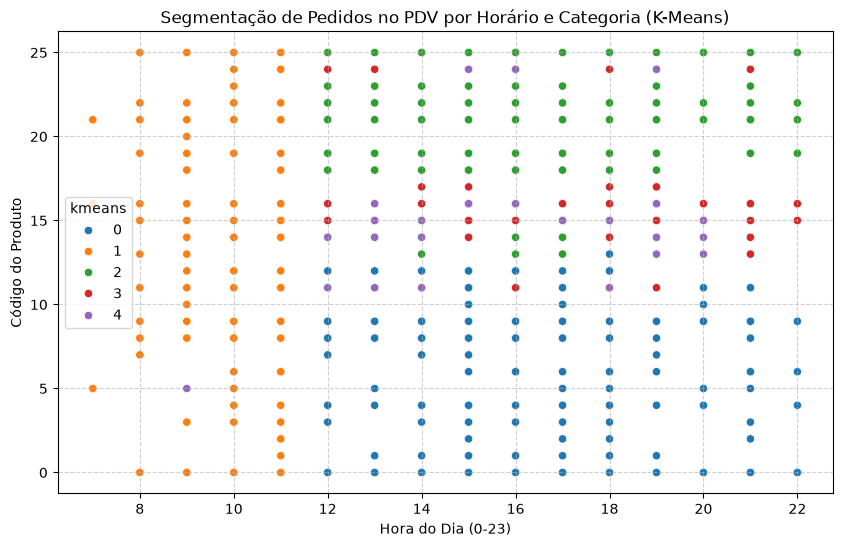

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Seleção de variáveis preditivas
features_cluster = df_cluster[['dia_horario', 'nome_produto_code', 'metodo_pagamento', 'turno', 'preco_unitario_item', 'quantidade_item']]

# Padronização
scaler = StandardScaler()
dataset_scaled = scaler.fit_transform(features_cluster)

# Ajuste do K-Means com semente determinística fixada
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init='auto')
df_cluster['kmeans'] = kmeans.fit_predict(dataset_scaled)

# Visualização de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x='dia_horario',
    y='nome_produto_code',
    hue='kmeans',
    palette='tab10'
)
plt.title('Segmentação de Pedidos no PDV por Horário e Categoria (K-Means)')
plt.xlabel('Hora do Dia (0-23)')
plt.ylabel('Código do Produto')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()